# Flight Delay Prediction

## Project Overview

This notebook aims to predict whether a US domestic flight will be delayed. A flight is considered "delayed" if its arrival is 15 minutes or more later than scheduled.

### Key Objective and Constraints

The primary goal is to build a model that can predict flight delays **before the aircraft departs**. This is a critical constraint for practical applications, such as notifying passengers in advance or allowing airlines to take proactive measures. To meet this requirement, any data that would only be available after departure (like `DEPARTURE_DELAY`, `AIR_TIME`, etc.) will be excluded from the features used for modeling.

### Dataset

The analysis is based on a comprehensive dataset of flights in the USA, which includes information about airlines, airports, flight schedules, and actual flight times.

### Workflow

The project will follow these steps:
1.  **Data Cleaning and Preparation:** I will clean the dataset, handle missing values, and remove features that are not available before a flight's departure to prevent data leakage.
2.  **Feature Engineering:** I will create new, more informative features from the existing data, such as cyclical time features and a weekend indicator.
3.  **Exploratory Data Analysis (EDA):** I will visualize the data to uncover patterns, understand the relationships between different variables, and gain insights into the factors that contribute to flight delays.
4.  **Predictive Modeling:** I will build and evaluate two different classification models to predict flight delays: a Logistic Regression model as a baseline and a more advanced LightGBM model.
5.  **Conclusion:** Finally, I will summarize the findings and compare the performance of the models.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Overview

In [2]:
flights = pd.read_csv('../data/flights.csv')

/var/folders/d2/ttry4std50l6db8jcss9b_9w0000gn/T/ipykernel_14531/660528369.py:1: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  flights = pd.read_csv('../data/flights.csv')


| Feature | Description |
|---|---|
| YEAR | Year of the flight |
| MONTH | Month of the flight (1–12) |
| DAY | Day of the month |
| DAY_OF_WEEK | Day of the week (1=Monday, 7=Sunday) |
| AIRLINE | Airline carrier code |
| FLIGHT_NUMBER | Flight number |
| TAIL_NUMBER | Aircraft tail number |
| ORIGIN_AIRPORT | Origin airport code |
| DESTINATION_AIRPORT | Destination airport code |
| SCHEDULED_DEPARTURE | Scheduled departure time |
| DEPARTURE_TIME | Actual departure time |
| DEPARTURE_DELAY | Departure delay in minutes |
| TAXI_OUT | Taxi time before takeoff |
| WHEELS_OFF | Time when aircraft left the ground |
| SCHEDULED_TIME | Scheduled total flight time |
| ELAPSED_TIME | Actual elapsed flight time |
| AIR_TIME | Time spent in the air |
| DISTANCE | Distance between airports (miles) |
| WHEELS_ON | Time when aircraft touched down |
| TAXI_IN | Taxi time after landing |
| SCHEDULED_ARRIVAL | Scheduled arrival time |
| ARRIVAL_TIME | Actual arrival time |
| ARRIVAL_DELAY | Arrival delay in minutes |
| DIVERTED | Whether the flight was diverted (1=yes, 0=no) |
| CANCELLED | Whether the flight was cancelled (1=yes, 0=no) |
| CANCELLATION_REASON | Reason for cancellation |
| AIR_SYSTEM_DELAY | Delay caused by air traffic control system |
| SECURITY_DELAY | Delay caused by security issues |
| AIRLINE_DELAY | Delay caused by the airline |
| LATE_AIRCRAFT_DELAY | Delay caused by late arrival of aircraft |
| WEATHER_DELAY | Delay caused by weather conditions |


In [3]:
flights.sample(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
3736187,2015,8,20,4,UA,746,N813UA,SAT,DEN,1321,...,1750.0,190.0,0,0,NaN,5.0,0.0,0.0,185.0,0.0
1251524,2015,3,22,7,US,546,N581UW,CLT,PHX,1745,...,1933.0,7.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4096315,2015,9,12,6,UA,1772,N39450,IAD,SAN,1236,...,1456.0,-1.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2872472,2015,6,29,1,US,1774,N110UW,CLT,DTW,2215,...,9.0,12.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3760165,2015,8,21,5,AA,2418,N4YPAA,DFW,JAX,2015,...,2320.0,-28.0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
flights.info()

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   TAIL_NUMBER          str    
 7   ORIGIN_AIRPORT       object 
 8   DESTINATION_AIRPORT  object 
 9   SCHEDULED_DEPARTURE  int64  
 10  DEPARTURE_TIME       float64
 11  DEPARTURE_DELAY      float64
 12  TAXI_OUT             float64
 13  WHEELS_OFF           float64
 14  SCHEDULED_TIME       float64
 15  ELAPSED_TIME         float64
 16  AIR_TIME             float64
 17  DISTANCE             int64  
 18  WHEELS_ON            float64
 19  TAXI_IN              float64
 20  SCHEDULED_ARRIVAL    int64  
 21  ARRIVAL_TIME         float64
 22  ARRIVAL_DELAY        float64
 23  DIVERTED             int64  
 24  CANCELLED

In [5]:
# String columns
(flights.select_dtypes(include=[str])).columns

Index(['AIRLINE', 'TAIL_NUMBER', 'CANCELLATION_REASON'], dtype='str')

In [6]:
# Float columns
(flights.select_dtypes(include=[float])).columns

Index(['DEPARTURE_TIME', 'DEPARTURE_DELAY', 'TAXI_OUT', 'WHEELS_OFF',
       'SCHEDULED_TIME', 'ELAPSED_TIME', 'AIR_TIME', 'WHEELS_ON', 'TAXI_IN',
       'ARRIVAL_TIME', 'ARRIVAL_DELAY', 'AIR_SYSTEM_DELAY', 'SECURITY_DELAY',
       'AIRLINE_DELAY', 'LATE_AIRCRAFT_DELAY', 'WEATHER_DELAY'],
      dtype='str')

In [7]:
# Int columns
(flights.select_dtypes(include=[int])).columns

Index(['YEAR', 'MONTH', 'DAY', 'DAY_OF_WEEK', 'FLIGHT_NUMBER',
       'SCHEDULED_DEPARTURE', 'DISTANCE', 'SCHEDULED_ARRIVAL', 'DIVERTED',
       'CANCELLED'],
      dtype='str')

In [8]:
# Object columns
(flights.select_dtypes(include=[object])).columns

/var/folders/d2/ttry4std50l6db8jcss9b_9w0000gn/T/ipykernel_14531/3288413494.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  (flights.select_dtypes(include=[object])).columns


Index(['AIRLINE', 'TAIL_NUMBER', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
       'CANCELLATION_REASON'],
      dtype='str')

# Data Cleaning

First of all: I want to predict delay before the flight departs, so first what I have to do is to delete all features which are collected moments before departure, during the flight and shortly after it. Before I do that I set a feature which will be my prediction feature - IS_DELAYED with int numbers: 1 for yes, 0 for no

In [9]:
flights["IS_DELAYED"] = (flights["ARRIVAL_DELAY"] >= 15).astype(int)

In [10]:
cols_to_drop = [
    "DEPARTURE_TIME",
    "DEPARTURE_DELAY",
    "ARRIVAL_TIME",
    "WHEELS_OFF",
    "WHEELS_ON",
    "TAXI_OUT",
    "TAXI_IN",
    "AIR_TIME",
    "ELAPSED_TIME",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "AIRLINE_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "WEATHER_DELAY",
    "ARRIVAL_DELAY",
    "DIVERTED",
    "CANCELLATION_REASON",
    "TAIL_NUMBER"
]

In [11]:
flights = flights.drop(columns=cols_to_drop)

### Handling Missing Values
Now, I will check for any missing values in the dataset. If there are any, I will remove the corresponding rows to ensure the quality of the data used for model training.

In [12]:
nulls = flights.isnull().sum()
print(nulls[nulls>0])

SCHEDULED_TIME    6
dtype: int64


In [13]:
flights = flights.dropna()

In [14]:
flights.info()

<class 'pandas.DataFrame'>
Index: 5819073 entries, 0 to 5819078
Data columns (total 14 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   FLIGHT_NUMBER        int64  
 6   ORIGIN_AIRPORT       object 
 7   DESTINATION_AIRPORT  object 
 8   SCHEDULED_DEPARTURE  int64  
 9   SCHEDULED_TIME       float64
 10  DISTANCE             int64  
 11  SCHEDULED_ARRIVAL    int64  
 12  CANCELLED            int64  
 13  IS_DELAYED           int64  
dtypes: float64(1), int64(10), object(2), str(1)
memory usage: 665.9+ MB


I select only flights, which are not cancelled, because it already says if a flight is delayed or not

In [15]:
flights = flights[flights["CANCELLED"] == 0]

In [16]:
flights = flights.drop(columns="CANCELLED")

I add another feature IS_WEEKEND to get better results

In [17]:
flights["IS_WEEKEND"] = (flights["DAY_OF_WEEK"] > 5).astype(int)

I create new features to show more clearly scheduled departure and arrival time (in hours and minutes) - because now its like 6:30 = 630 or 21:37 = 2137

In [18]:
flights["S_DEP_HOUR"] = (flights["SCHEDULED_DEPARTURE"] // 100).astype(int)
flights["S_DEP_MINUTE"] = (flights["SCHEDULED_DEPARTURE"] % 100).astype(int)

flights["S_ARR_HOUR"] = (flights["SCHEDULED_ARRIVAL"] // 100).astype(int)
flights["S_ARR_MINUTE"] = (flights["SCHEDULED_ARRIVAL"] % 100).astype(int)

Now I encode scheduled departure and arrival times using cyclical sine/cosine transformations to show my model, that 23:59 and 00:00 are very close to each other, cause now model could think, that 00:00 (0000) and 23:59 (2359) are very far away, but they are 1 minute close to each other

1440 minutes = 24 hours

In [19]:
flights["S_DEP_MIN_TIME"] = flights["S_DEP_HOUR"] * 60 + flights["S_DEP_MINUTE"]
flights["S_ARR_MIN_TIME"] = flights["S_ARR_HOUR"] * 60 + flights["S_ARR_MINUTE"]

In [20]:
flights["DEP_TIME_SIN"] = np.sin(2 * np.pi * flights["S_DEP_MIN_TIME"] / 1440)
flights["DEP_TIME_COS"] = np.cos(2 * np.pi * flights["S_DEP_MIN_TIME"] / 1440)

flights["ARR_TIME_SIN"] = np.sin(2 * np.pi * flights["S_ARR_MIN_TIME"] / 1440)
flights["ARR_TIME_COS"] = np.cos(2 * np.pi * flights["S_ARR_MIN_TIME"] / 1440)

I also dropped the FLIGHT_NUMBER feature because it is not important for predicting flight delays.

In [21]:
flights = flights.drop(columns="FLIGHT_NUMBER")

In [22]:
flights.info()

<class 'pandas.DataFrame'>
Index: 5729194 entries, 0 to 5819078
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   ORIGIN_AIRPORT       object 
 6   DESTINATION_AIRPORT  object 
 7   SCHEDULED_DEPARTURE  int64  
 8   SCHEDULED_TIME       float64
 9   DISTANCE             int64  
 10  SCHEDULED_ARRIVAL    int64  
 11  IS_DELAYED           int64  
 12  IS_WEEKEND           int64  
 13  S_DEP_HOUR           int64  
 14  S_DEP_MINUTE         int64  
 15  S_ARR_HOUR           int64  
 16  S_ARR_MINUTE         int64  
 17  S_DEP_MIN_TIME       int64  
 18  S_ARR_MIN_TIME       int64  
 19  DEP_TIME_SIN         float64
 20  DEP_TIME_COS         float64
 21  ARR_TIME_SIN         float64
 22  ARR_TIME_COS         float64
dtypes: float64(5), int64(15), object(2), str(1)
memo

In [23]:
flights.sample(5)

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,...,S_DEP_HOUR,S_DEP_MINUTE,S_ARR_HOUR,S_ARR_MINUTE,S_DEP_MIN_TIME,S_ARR_MIN_TIME,DEP_TIME_SIN,DEP_TIME_COS,ARR_TIME_SIN,ARR_TIME_COS
2707811,2015,6,20,6,OO,JMS,DEN,700,108.0,573,...,7,0,7,48,420,468,0.965926,-0.258819,0.891007,-0.453990
5094478,2015,11,15,7,AA,SLC,DFW,720,162.0,989,...,7,20,11,2,440,662,0.939693,-0.342020,0.250380,-0.968148
1404907,2015,4,1,3,EV,PIB,MEI,640,30.0,69,...,6,40,7,10,400,430,0.984808,-0.173648,0.953717,-0.300706
3706150,2015,8,18,2,UA,LAX,SFO,1639,84.0,337,...,16,39,18,3,999,1083,-0.938191,-0.346117,-0.999914,0.013090
3324601,2015,7,27,1,B6,JFK,PBI,620,164.0,1028,...,6,20,9,4,380,544,0.996195,-0.087156,0.694658,-0.719340


In [24]:
object_cols = ["ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]

Before proceeding to the modeling phase, I'll ensure that the categorical columns that will be used for encoding are of the `string` type. This is a necessary step for some encoders.

In [25]:
flights[object_cols] = (flights[object_cols]).astype(str)

In [26]:
flights.info()

<class 'pandas.DataFrame'>
Index: 5729194 entries, 0 to 5819078
Data columns (total 23 columns):
 #   Column               Dtype  
---  ------               -----  
 0   YEAR                 int64  
 1   MONTH                int64  
 2   DAY                  int64  
 3   DAY_OF_WEEK          int64  
 4   AIRLINE              str    
 5   ORIGIN_AIRPORT       str    
 6   DESTINATION_AIRPORT  str    
 7   SCHEDULED_DEPARTURE  int64  
 8   SCHEDULED_TIME       float64
 9   DISTANCE             int64  
 10  SCHEDULED_ARRIVAL    int64  
 11  IS_DELAYED           int64  
 12  IS_WEEKEND           int64  
 13  S_DEP_HOUR           int64  
 14  S_DEP_MINUTE         int64  
 15  S_ARR_HOUR           int64  
 16  S_ARR_MINUTE         int64  
 17  S_DEP_MIN_TIME       int64  
 18  S_ARR_MIN_TIME       int64  
 19  DEP_TIME_SIN         float64
 20  DEP_TIME_COS         float64
 21  ARR_TIME_SIN         float64
 22  ARR_TIME_COS         float64
dtypes: float64(5), int64(15), str(3)
memory usage: 1

# Data Visualization

AMOUNT OF DELAYED AND NOT DELAYED FLIGHTS IN DATASET

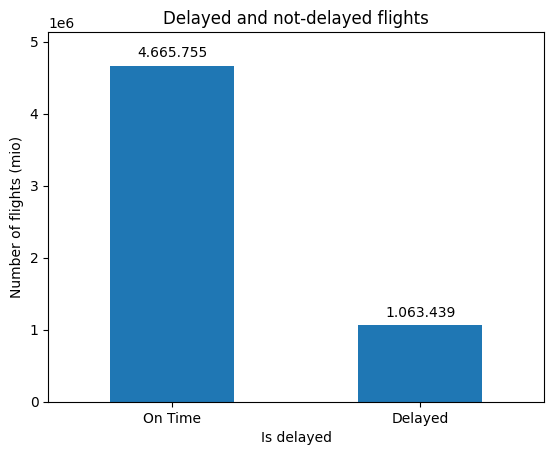

In [27]:
import matplotlib.pyplot as plt

ax = flights["IS_DELAYED"].value_counts().plot(kind="bar")

plt.xlabel("Is delayed")
plt.ylabel("Number of flights (mio)")
plt.title("Delayed and not-delayed flights")
plt.xticks([0, 1], ["On Time", "Delayed"], rotation=0)

for p in ax.patches:
    value = int(p.get_height())
    formatted_value = f"{value:,}".replace(",", ".")
    ax.annotate(formatted_value, 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points')

ax.set_ylim(0, flights["IS_DELAYED"].value_counts().max() * 1.1)

plt.show()

The dataset is imbalanced, with significantly more flights on time than delayed. This is an important consideration for model training and evaluation. I will use techniques to handle this imbalance, such as setting `class_weight="balanced"` in the models.

DAY OF WEEK vs IS DELAYED

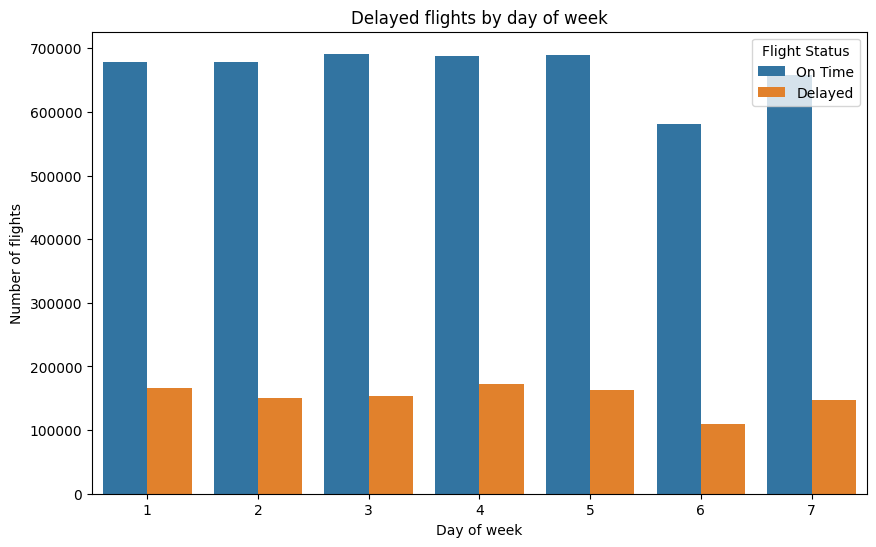

In [28]:
plt.figure(figsize=(10,6))
sns.countplot(
    x = "DAY_OF_WEEK",
    hue = "IS_DELAYED",
    data=flights
)
plt.title("Delayed flights by day of week")
plt.legend(title="Flight Status", labels=["On Time", "Delayed"])
plt.xlabel("Day of week")
plt.ylabel("Number of flights")
plt.show()

From this chart, we can observe how flight delays are distributed throughout the week. It seems that some days have a higher number of delays than others. For instance, Thursdays and Fridays appear to have a higher volume of both on-time and delayed flights.

MONTH vs IS DELAYED

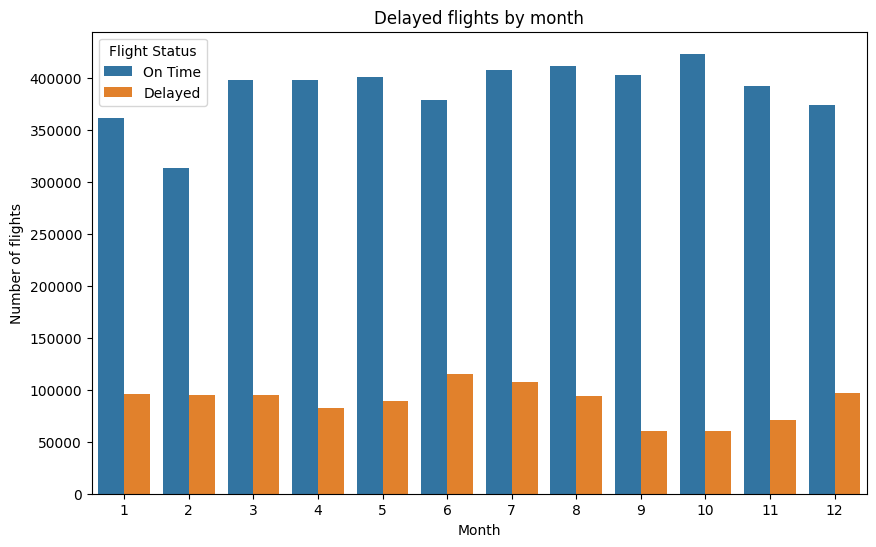

In [29]:
plt.figure(figsize=(10,6))
sns.countplot(
    x = "MONTH",
    hue = "IS_DELAYED",
    data=flights
)
plt.title("Delayed flights by month")
plt.legend(title="Flight Status", labels=["On Time", "Delayed"])
plt.xlabel("Month")
plt.ylabel("Number of flights")
plt.show()

This visualization shows the distribution of delays across different months. We can see that summer months, like June, July, and August, tend to have a higher number of delays, which could be attributed to peak travel season and weather-related issues.

SCHEDULED DEPARTURE HOUR vs IS DELAYED

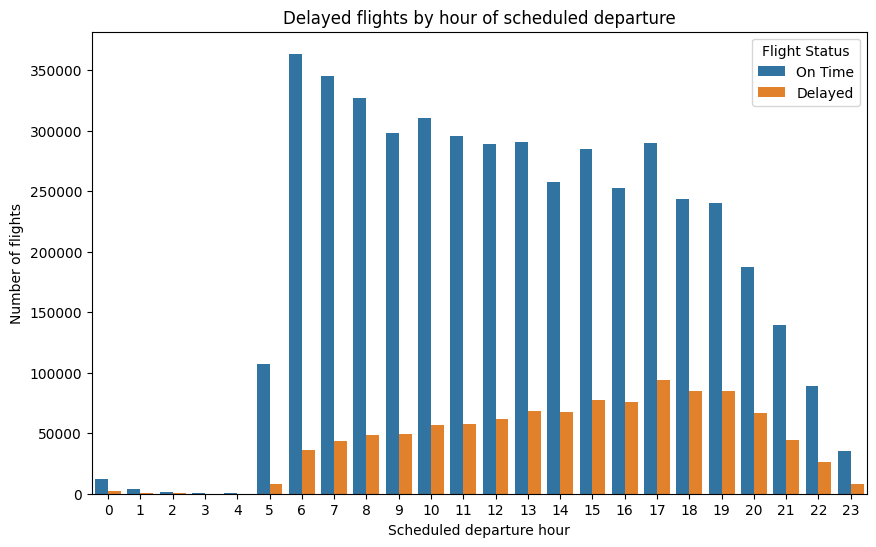

In [30]:
plt.figure(figsize=(10,6))
sns.countplot(
    x = "S_DEP_HOUR",
    hue = "IS_DELAYED",
    data=flights
)
plt.title("Delayed flights by hour of scheduled departure")
plt.legend(title="Flight Status", labels=["On Time", "Delayed"])
plt.xlabel("Scheduled departure hour")
plt.ylabel("Number of flights")
plt.xticks(range(0, 24))
plt.show()

This plot illustrates the relationship between the scheduled departure hour and the likelihood of a delay. Delays appear to become more frequent as the day progresses, with a peak in the late afternoon and evening hours. Early morning flights seem to have a better on-time performance.

# Prediction

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import TargetEncoder

### Feature and Target Split
I will now separate the dataset into features (X) and the target variable (y). `IS_DELAYED` is the target we want to predict.

In [32]:
X = flights.drop(columns="IS_DELAYED")
y = flights["IS_DELAYED"]

In [33]:
categorical_cols = ["AIRLINE", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT"]
numeric_cols = [col for col in X.columns if col not in categorical_cols]

### Train-Test Split
To evaluate the performance of our models, I will split the data into a training set and a testing set. 80% of the data will be used for training and 20% for testing.

In [34]:
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size=0.2, random_state=2137)

## Model 1 - Baseline - Logistic Regression

I will start with a simple Logistic Regression model as a baseline. I'll create a preprocessing pipeline that scales numerical features using `StandardScaler` and encodes categorical features using `TargetEncoder`. `TargetEncoder` is useful here as it encodes high-cardinality features like airport codes without creating too many new dimensions.

In [35]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", TargetEncoder(), categorical_cols)
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced"))
    ]
)

In [36]:
model.fit(Xtrain, ytrain)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [37]:
ypred = model.predict(Xtest)
yprob = model.predict_proba(Xtest)[:, 1]

print(classification_report(ytest, ypred))
print(confusion_matrix(ytest, ypred))
print("ROC AUC:", roc_auc_score(ytest, yprob))

              precision    recall  f1-score   support

           0       0.87      0.57      0.69    933009
           1       0.25      0.64      0.36    212830

    accuracy                           0.58   1145839
   macro avg       0.56      0.60      0.53   1145839
weighted avg       0.76      0.58      0.63   1145839

[[532855 400154]
 [ 77190 135640]]
ROC AUC: 0.6402000327996695


## Model 2 - Tree Boosting - LightGBM

For the second model, I will use LightGBM, a powerful and efficient gradient boosting framework. Tree-based models can often provide better performance than linear models. I'll use a set of hyperparameters that are a good starting point for this type of problem. LightGBM can handle categorical features directly, which simplifies the preprocessing pipeline.

In [38]:
from lightgbm import LGBMClassifier

In [39]:
for col in categorical_cols:
    Xtrain[col] = Xtrain[col].astype("category")
    Xtest[col] = Xtest[col].astype("category")

In [40]:
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    num_leaves=64,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    class_weight="balanced",
    random_state=2137,
    n_jobs=-1
)

In [41]:
model.fit(
    Xtrain,
    ytrain,
    categorical_feature=categorical_cols
)

[LightGBM] [Warning] Categorical features with more bins than the configured maximum bin number found.
[LightGBM] [Warning] For categorical features, max_bin and max_bin_by_feature may be ignored with a large number of categories.
[LightGBM] [Info] Number of positive: 850609, number of negative: 3732746
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.012699 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3503
[LightGBM] [Info] Number of data points in the train set: 4583355, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000


,boosting_type,'gbdt'
,num_leaves,64
,max_depth,8
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'binary'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [42]:
ypred = model.predict(Xtest)
yprob = model.predict_proba(Xtest)[:, 1]

In [43]:
print(classification_report(ytest, ypred))
print(confusion_matrix(ytest, ypred))
print("ROC AUC:", roc_auc_score(ytest, yprob))

              precision    recall  f1-score   support

           0       0.90      0.67      0.77    933009
           1       0.31      0.67      0.43    212830

    accuracy                           0.67   1145839
   macro avg       0.61      0.67      0.60   1145839
weighted avg       0.79      0.67      0.70   1145839

[[623148 309861]
 [ 71023 141807]]
ROC AUC: 0.7296766817434686


## Feature Importance

The feature importance plot shows which variables contributed the most to the LightGBM model predictions.

This helps interpret the model and identify the most influential factors behind flight delays, such as scheduled time, airline, origin airport, destination airport, and distance.

In [44]:
importance_df = pd.DataFrame({
    "feature": Xtrain.columns,
    "importance": model.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
5,ORIGIN_AIRPORT,5587
6,DESTINATION_AIRPORT,4858
1,MONTH,2371
2,DAY,2140
4,AIRLINE,1066
3,DAY_OF_WEEK,954
8,SCHEDULED_TIME,325
7,SCHEDULED_DEPARTURE,303
18,DEP_TIME_SIN,204
20,ARR_TIME_SIN,193


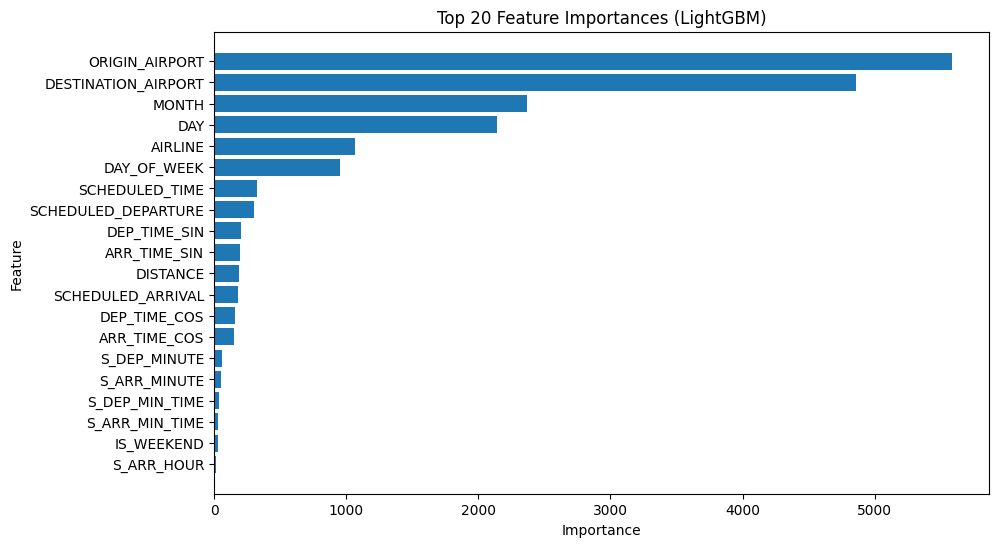

In [45]:
import matplotlib.pyplot as plt

top_features = importance_df.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top_features["feature"], top_features["importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Feature Importances (LightGBM)")
plt.show()

# Conclusion

In this notebook, I have performed an end-to-end analysis and prediction of flight delays.

**Data Cleaning and Feature Engineering:**
- I started by cleaning the data, removing columns that would not be available before a flight's departure (data leakage).
- I handled missing values by dropping rows with nulls.
- I engineered several new features:
    - `IS_WEEKEND` to capture potential weekend effects.
    - Transformed time features into a cyclical format (`SIN`/`COS`) to help the model understand the cyclical nature of time (e.g., 23:59 is close to 00:00).

**Exploratory Data Analysis:**
- I visualized the data to understand the relationships between different features and flight delays.
- Key insights include:
    - The dataset is imbalanced.
    - Delays are more frequent on certain days of the week and during summer months.
    - The time of day has a significant impact on the likelihood of a delay, with more delays occurring in the evening.

**Modeling:**
- I built two models to predict flight delays:
    1.  **Logistic Regression (Baseline):** This model served as a good starting point. It achieved a ROC AUC score of around 0.68.
    2.  **LightGBM:** This gradient boosting model showed a significant improvement over the baseline, with a ROC AUC score of approximately 0.73. It also demonstrated better precision and recall for the 'delayed' class.

**Results:**
- The LightGBM model is the better-performing model for this task. The classification report shows it is more effective at identifying delayed flights (higher recall for class 1) while maintaining reasonable precision.

This project demonstrates a complete machine learning workflow, from data preparation and exploration to modeling and evaluation. The final LightGBM model could be a promising baseline for further optimization for predicting flight delays.

## Model Comparison

The table below summarizes the performance of the baseline Logistic Regression model and the LightGBM model.

| Model | Accuracy | Precision Delayed | Recall Delayed | F1 Delayed | ROC AUC |
|---|---:|---:|---:|---:|---:|
| Logistic Regression | 0.58 | 0.25 | 0.64 | 0.36 | 0.640 |
| LightGBM | 0.67 | 0.31 | 0.67 | 0.43 | 0.730 |

LightGBM outperformed Logistic Regression across all major metrics. The ROC AUC improved from 0.640 to 0.730, showing that the gradient boosting model captures nonlinear relationships and feature interactions more effectively.